In [1]:
from src.dataset_loader import DatasetLoader
from src.features import FeatureExtractor
from src.eda import EDAAnalyzer
from src.embedding import UMAPEmbedding
from src.visualization import Visualizer
from src.classifier import DataSplitter
from src.classifier import ConsumerClassifier
from src.classification_analysis import ClassificationAnalyzer
from src.consumption_profiles import ConsumptionProfileBuilder
from src.anomaly_features import AnomalyFeatureExtractor
from src.isolation_forest_detector import IsolationForestDetector
from src.visualizer import AnomalyVisualizer
from src.anomaly_embedding import AnomalyUMAP
from src.risk_scorer import RiskScorer
from src.anomaly_analizer import AnomalyAnalyzer


In [2]:
print("\n========== STEP 1: LOAD DATA ==========")

loader = DatasetLoader("data/raw")
df = loader.load_all()
print("Loaded shape:", df.shape)




========== STEP 1: LOAD DATA ==========
Loading: halfhours_group_9.csv
Loading: halfhours_group_8.csv
Loading: halfhours_group_5.csv
Loading: halfhours_group_14.csv
Loading: halfhours_group_15.csv
Loading: halfhours_group_4.csv
Loading: halfhours_group_6.csv
Loading: halfhours_group_16.csv
Loading: halfhours_group_7.csv
Loading: halfhours_group_3.csv
Loading: halfhours_group_12.csv
Loading: halfhours_group_13.csv
Loading: halfhours_group_2.csv
Loading: halfhours_group_11.csv
Loading: halfhours_group_10.csv
Loading: halfhours_group_1.csv
Loaded shape: (37389419, 7)


In [3]:
print("\n========== STEP 2: FEATURE EXTRACTION ==========")

extractor = FeatureExtractor()
features_df = extractor.extract(df)
features_df.to_csv("data/processed/features.csv",index=False)
print("Features saved")


========== STEP 2: FEATURE EXTRACTION ==========
Features saved


In [4]:
print("\n========== STEP 3: EDA ==========")

eda = EDAAnalyzer()
eda.basic_info(features_df)
eda.class_distribution(features_df)
summary = eda.numerical_summary(features_df)
missing = eda.missing_report(features_df)
constants = eda.constant_features(features_df)
print("\nConstant features:")
print(constants)


========== STEP 3: EDA ==========

===== DATASET INFO =====
Rows: 7573
Columns: 50

===== COLUMN TYPES =====
meter_id                object
consumer_class          object
A+_mean                float64
A+_std                 float64
A+_min                 float64
A+_max                 float64
A+_median              float64
A+_p95                 float64
A+_p5                  float64
A+_cv                  float64
A+_fft_max             float64
A+_fft_mean            float64
A+_fft_energy          float64
A-_mean                float64
A-_std                 float64
A-_min                 float64
A-_max                 float64
A-_median              float64
A-_p95                 float64
A-_p5                  float64
A-_cv                  float64
A-_fft_max             float64
A-_fft_mean            float64
A-_fft_energy          float64
R+_mean                float64
R+_std                 float64
R+_min                 float64
R+_max                 float64
R+_median             


========== STEP 4: UMAP ==========


/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


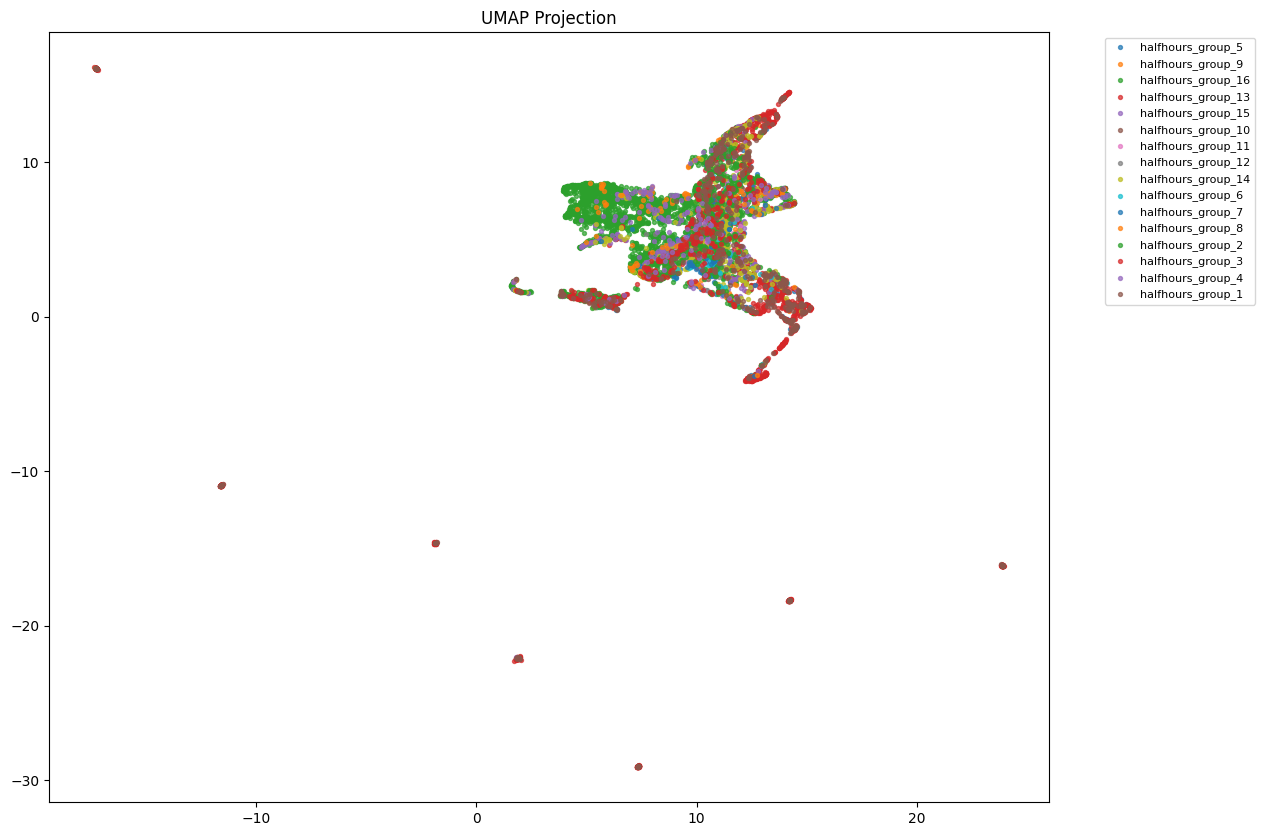

In [5]:
print("\n========== STEP 4: UMAP ==========")

embedder = UMAPEmbedding()
embedding_df = embedder.fit_transform(features_df)
visualizer = Visualizer()
visualizer.plot_umap(embedding_df)

In [6]:
print("\n========== STEP 5: CLASSIFICATION ==========")

splitter = DataSplitter()
X_train, X_test, y_train, y_test = (splitter.split(features_df))
classifier = ConsumerClassifier()
model, y_pred = classifier.train(X_train, X_test, y_train, y_test)


========== STEP 5: CLASSIFICATION ==========

===== CLASSIFICATION REPORT =====
                    precision    recall  f1-score   support

 halfhours_group_1       0.63      0.42      0.51        92
halfhours_group_10       0.33      0.08      0.13        12
halfhours_group_11       0.50      0.07      0.12        14
halfhours_group_12       0.00      0.00      0.00         6
halfhours_group_13       0.79      0.95      0.86       310
halfhours_group_14       0.58      0.53      0.55       100
halfhours_group_15       0.60      0.60      0.60       117
halfhours_group_16       0.88      0.96      0.92       476
 halfhours_group_2       0.69      0.91      0.79       176
 halfhours_group_3       0.68      0.67      0.68        70
 halfhours_group_4       1.00      0.11      0.20        27
 halfhours_group_5       0.92      0.41      0.57        29
 halfhours_group_6       0.80      0.52      0.63        23
 halfhours_group_7       0.73      0.32      0.44        25
 halfhours_group_8

/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz


========== STEP 6: MODEL ANALYSIS ==========


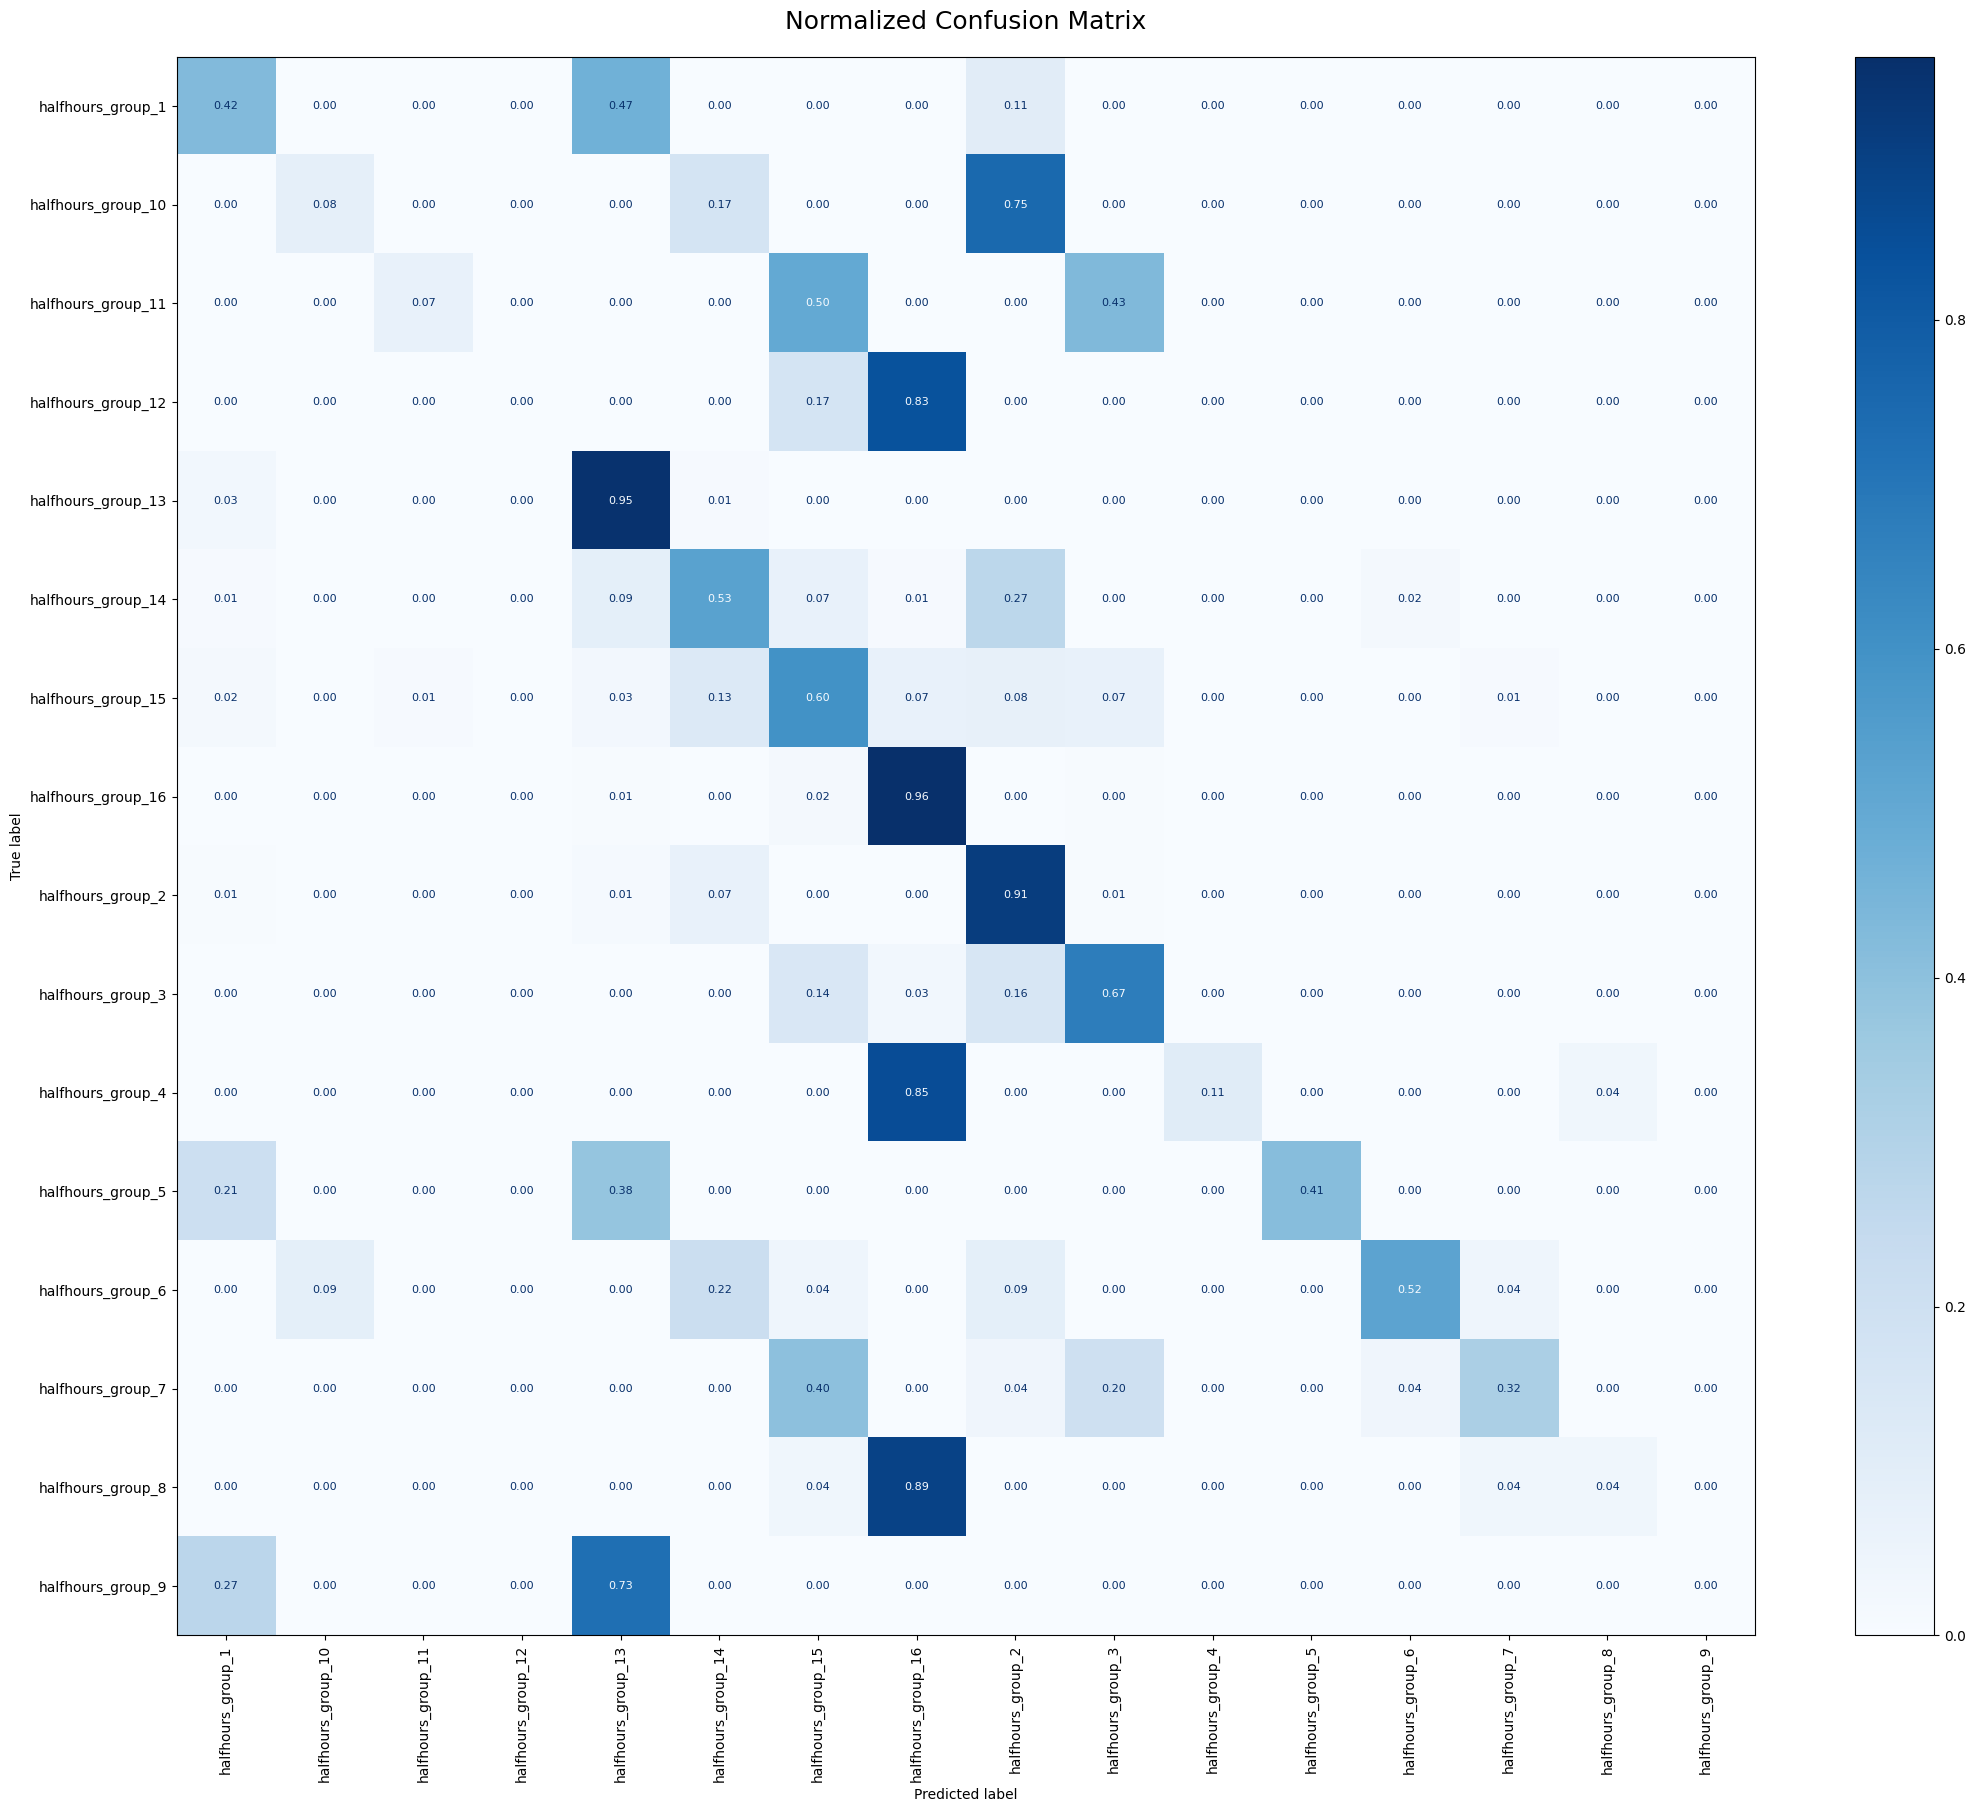


Top Feature Importances:
A+_fft_max: 0.1162
A+_fft_energy: 0.0824
A+_mean: 0.0649
apparent_power_mean: 0.0640
A+_p95: 0.0492
A+_median: 0.0479
A+_fft_mean: 0.0420
A+_std: 0.0326
A+_max: 0.0297
apparent_power_std: 0.0252
A+_cv: 0.0251
R-_p95: 0.0218
R-_fft_max: 0.0213
R+_fft_mean: 0.0211
R-_fft_energy: 0.0206
A+_p5: 0.0195
R-_std: 0.0187
R-_fft_mean: 0.0184
R-_mean: 0.0183
R+_cv: 0.0180


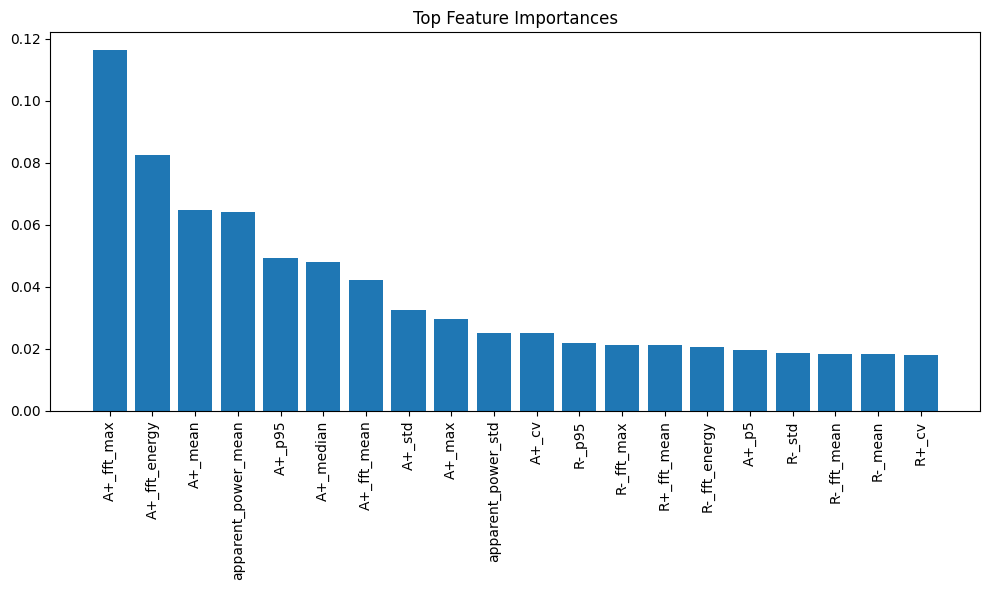

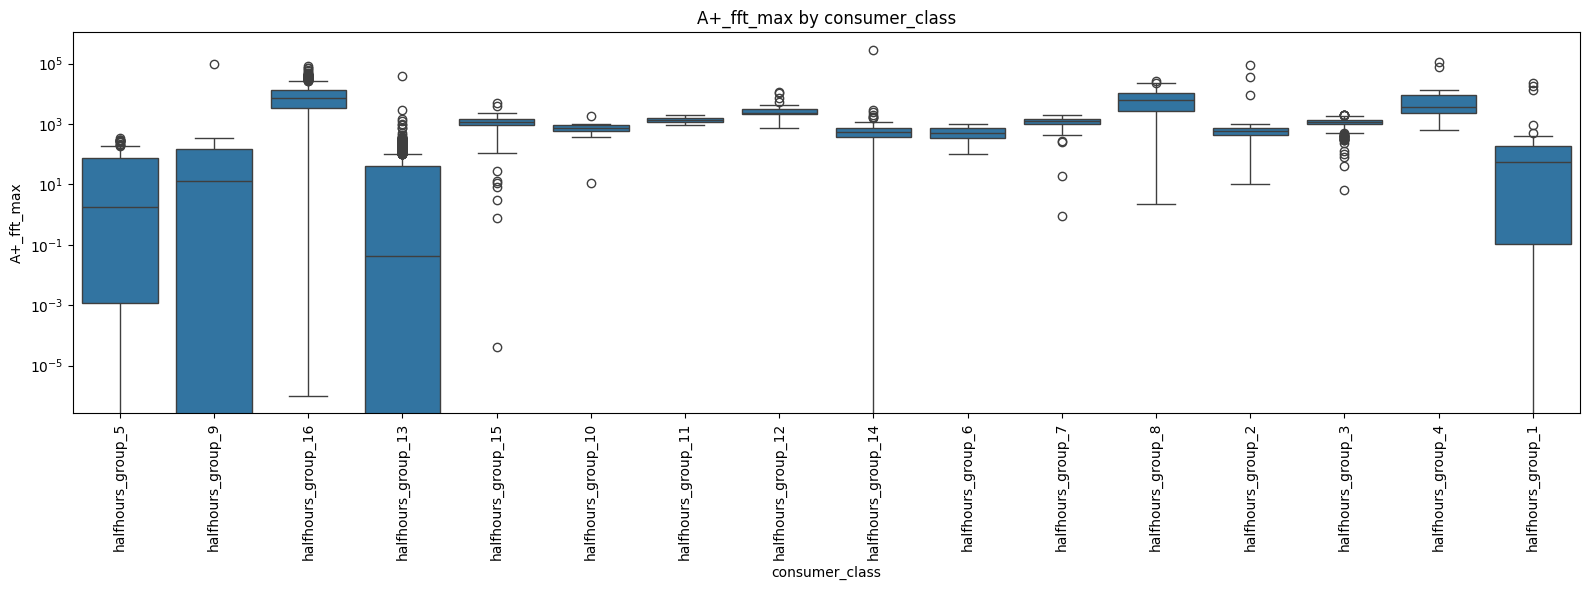

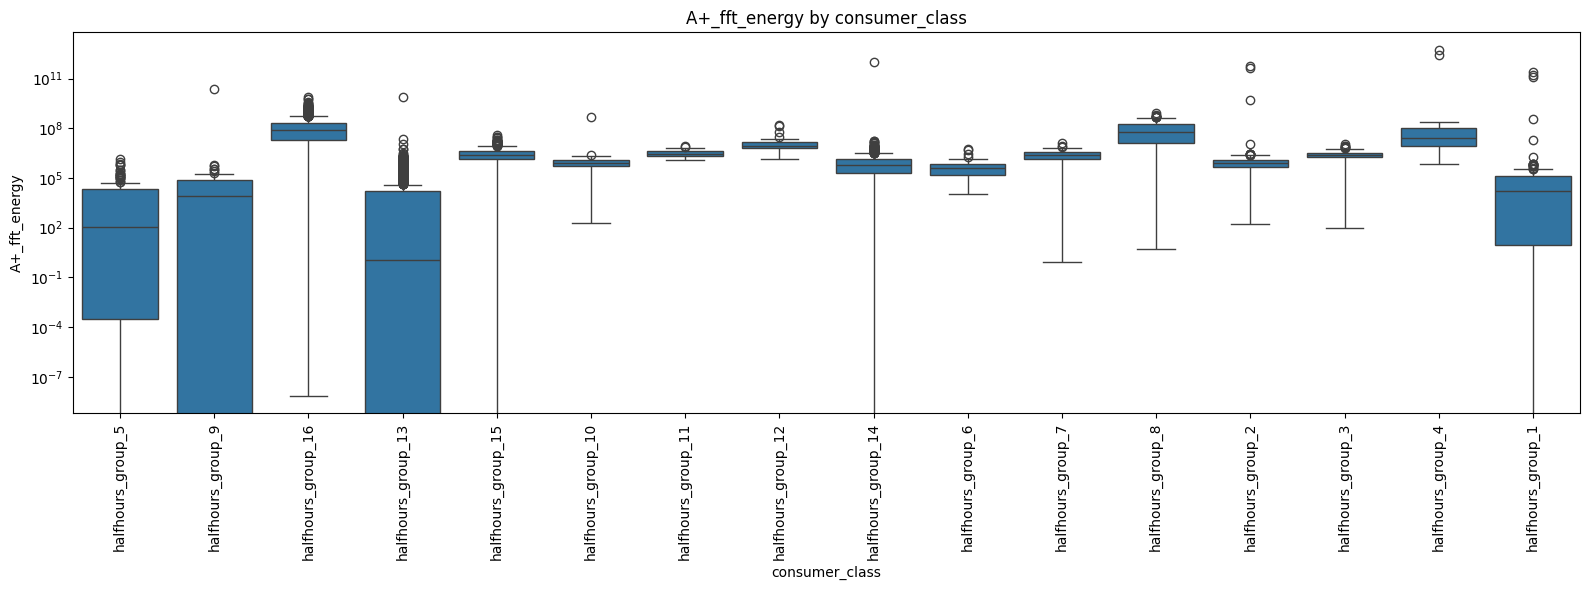

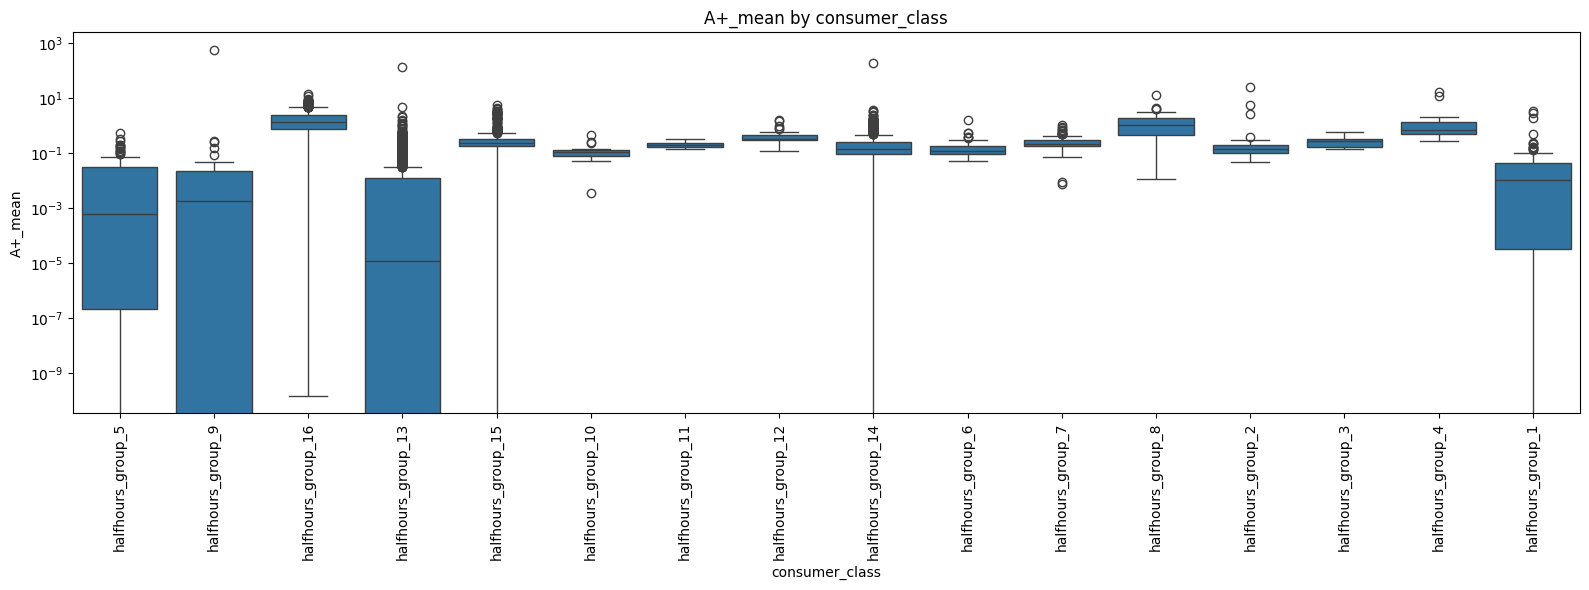

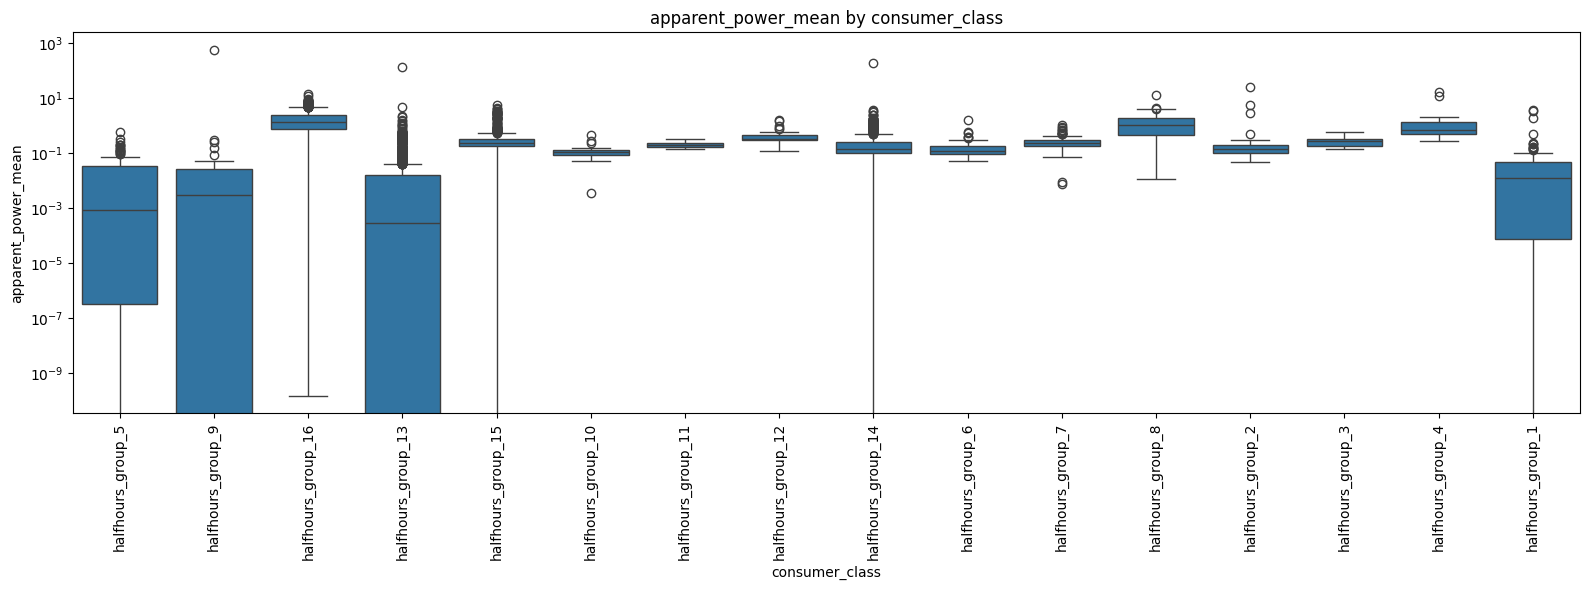

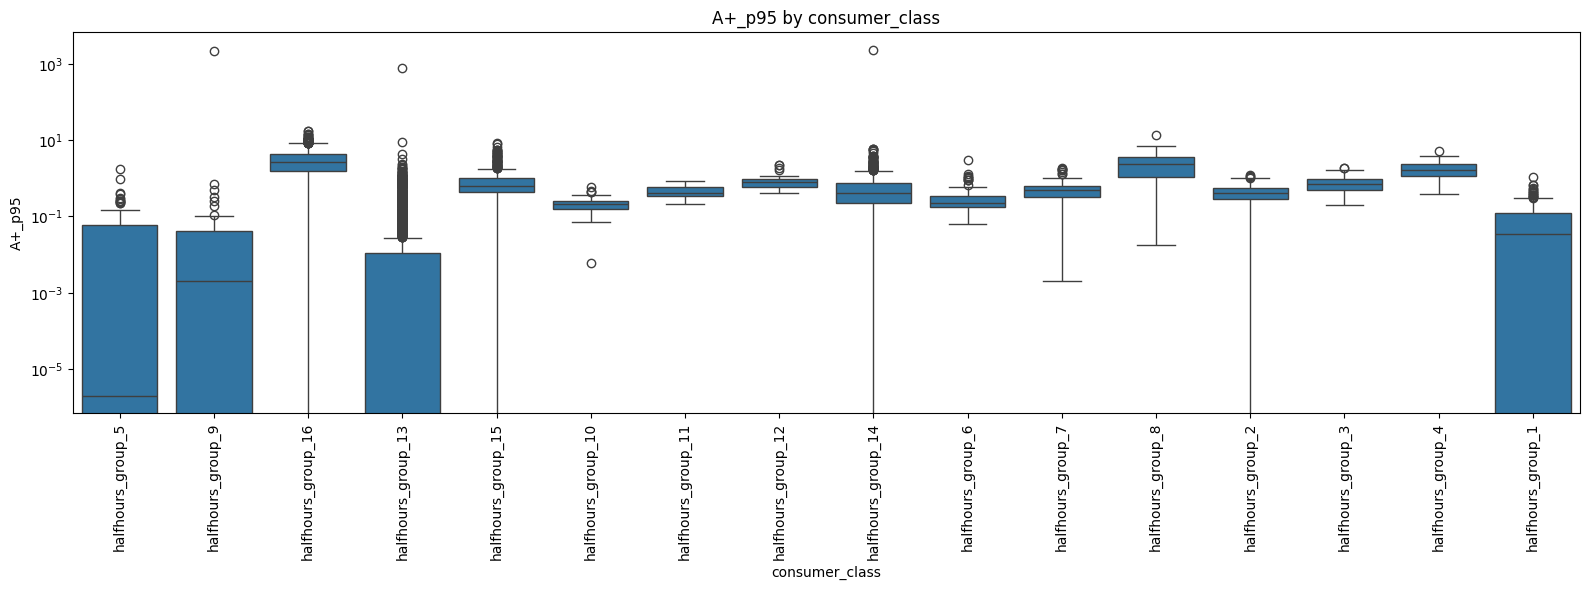

In [7]:

print("\n========== STEP 6: MODEL ANALYSIS ==========")

analyzer = ClassificationAnalyzer()
analyzer.plot_confusion_matrix(y_test,y_pred)

analyzer.feature_importance(model,features_df.drop(columns=["meter_id","consumer_class"]).columns)
top_features = ["A+_fft_max",
    "A+_fft_energy",
    "A+_mean",
    "apparent_power_mean",
    "A+_p95"]
for feature in top_features:
    analyzer.boxplot_features( features_df, feature, "consumer_class")

In [8]:
print("\n========== STEP 7: CONSUMPTION PROFILES ==========")

profile_builder = ConsumptionProfileBuilder()
profiles = profile_builder.build(df)
profiles.to_csv("data/processed/meter_profiles.csv",index=False)
print("Meter profiles saved")
print("Profiles shape:", profiles.shape)



========== STEP 7: CONSUMPTION PROFILES ==========
Meter profiles saved
Profiles shape: (7573, 38)


In [9]:
print("\n========== STEP 8: ANOMALY FEATURES ==========")

anomaly_feature_extractor = (AnomalyFeatureExtractor())
anomaly_features = (anomaly_feature_extractor.extract(df))
anomaly_features.to_csv( "data/processed/anomaly_features.csv",index=False)
print("Anomaly features saved")


========== STEP 8: ANOMALY FEATURES ==========
Anomaly features saved


In [10]:
print("\n========== STEP 9: ISOLATION FOREST ==========")

detector = IsolationForestDetector()
anomaly_scores = detector.detect(anomaly_features)
anomaly_scores.to_csv("data/processed/anomaly_scores.csv",index=False)
top_anomalies = (anomaly_scores.sort_values("anomaly_score").head(50))
print("Top anomalies:")
print(top_anomalies[["meter_id", "anomaly_score"]])
top_anomalies.to_csv("data/processed/top_anomalies.csv", index=False)
print("Top anomalies saved")



========== STEP 9: ISOLATION FOREST ==========
Top anomalies:
                     meter_id  anomaly_score
387   04:97:90:00:11:1D:BE:08      -0.757807
217   04:97:90:00:11:1B:51:20      -0.755064
539   04:97:90:00:11:1F:0E:0D      -0.735863
538   04:97:90:00:11:1F:0D:C5      -0.735163
614   04:97:90:00:11:20:F3:5C      -0.728564
331   04:97:90:00:11:1D:A3:69      -0.719629
349   04:97:90:00:11:1D:AC:C3      -0.715367
530   04:97:90:00:11:1F:07:68      -0.714627
5843  04:97:90:00:11:57:B6:46      -0.710283
3018  04:97:90:00:11:49:00:A6      -0.708116
3670  04:97:90:00:11:49:EE:AB      -0.705966
4992  04:97:90:00:11:4A:DB:5A      -0.704660
1206  04:97:90:00:11:2A:17:A0      -0.704435
7357  04:97:90:01:F0:08:EF:27      -0.704244
2556  04:97:90:00:11:42:BD:54      -0.704203
680   04:97:90:00:11:22:03:75      -0.701976
2137  04:97:90:00:11:42:6A:8B      -0.699631
6391  04:97:90:01:F0:04:82:6C      -0.698031
7368  04:97:90:01:F0:08:FC:52      -0.697124
2854  04:97:90:00:11:42:F2:49      -0


========== STEP 10: ANOMALY UMAP ==========


/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


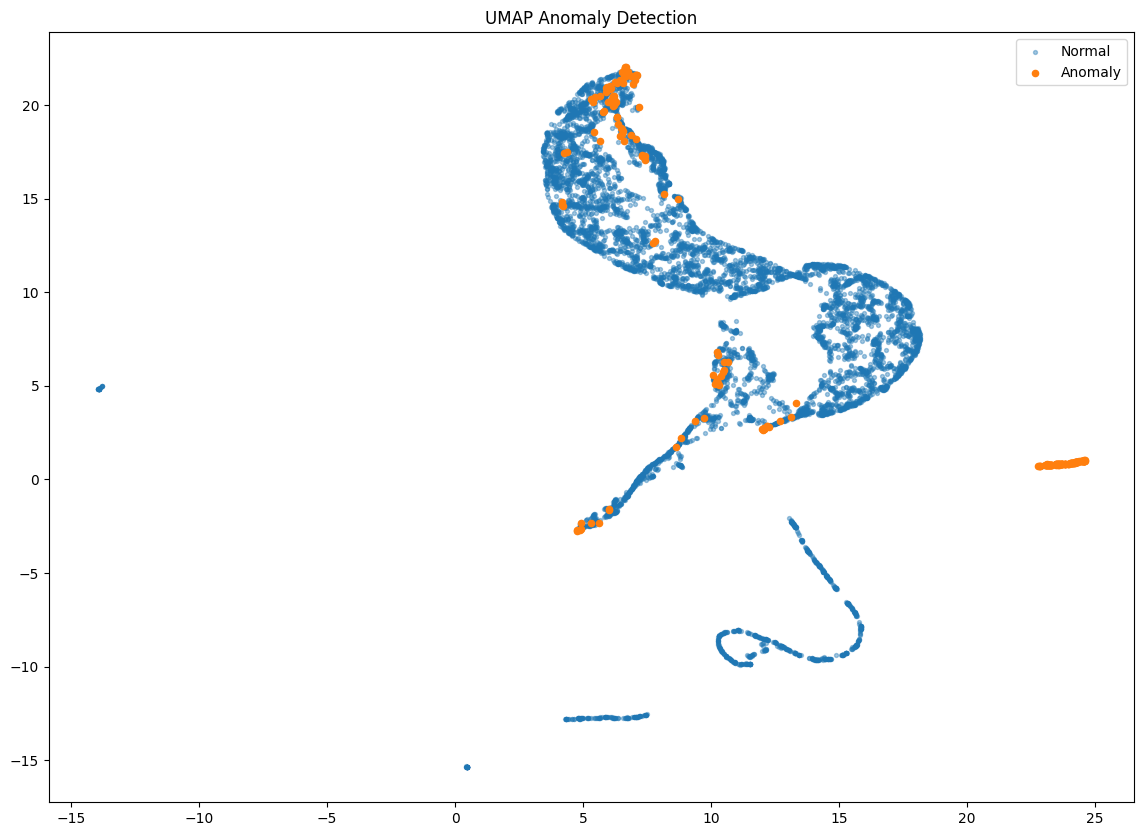

In [11]:
print("\n========== STEP 10: ANOMALY UMAP ==========")

anomaly_embedder = (AnomalyUMAP())
anomaly_embedding = (anomaly_embedder.fit_transform(anomaly_scores))
anomaly_embedding["anomaly"] = (anomaly_scores["anomaly"].values)
anomaly_visualizer = (AnomalyVisualizer())
anomaly_visualizer.plot( anomaly_embedding)

In [12]:

print("\n========== STEP 11: RISK SCORING ==========")

scorer = RiskScorer()
risk_report = scorer.calculate_risk(anomaly_scores_df=anomaly_scores,
    meter_profiles_df=profiles,
    anomaly_features_df=anomaly_features)

if "consumer_class" not in risk_report.columns:
    meter_classes = (df[["meter_id", "consumer_class"]].drop_duplicates())
    risk_report["meter_id"] = risk_report["meter_id"].astype(str).str.strip()
    meter_classes["meter_id"] = meter_classes["meter_id"].astype(str).str.strip()
    risk_report = risk_report.merge(meter_classes, on="meter_id", how="left")
risk_report.to_csv("data/processed/final_risk_report.csv", index=False)

print(risk_report[["meter_id", "risk_score", "consumer_class"]].head(10))


========== STEP 11: RISK SCORING ==========
                     meter_id  risk_score      consumer_class
3670  04:97:90:00:11:49:EE:AB       55.56  halfhours_group_13
4992  04:97:90:00:11:4A:DB:5A       54.99  halfhours_group_13
7357  04:97:90:01:F0:08:EF:27       54.07   halfhours_group_1
1206  04:97:90:00:11:2A:17:A0       53.90  halfhours_group_13
2556  04:97:90:00:11:42:BD:54       53.77  halfhours_group_13
3018  04:97:90:00:11:49:00:A6       53.56  halfhours_group_13
680   04:97:90:00:11:22:03:75       53.44   halfhours_group_5
2137  04:97:90:00:11:42:6A:8B       53.04  halfhours_group_13
2854  04:97:90:00:11:42:F2:49       51.87  halfhours_group_13
6391  04:97:90:01:F0:04:82:6C       51.47   halfhours_group_1


In [13]:
print("\n========== STEP 12: GENERATE REPORTS ==========")

anomaly_analyzer = AnomalyAnalyzer(output_dir="image/reports")
top_risk_objects = (risk_report.head(5))
for _, row in top_risk_objects.iterrows():
    anomaly_analyzer.plot_anomaly_vs_normal(raw_df=df,
        meter_profiles_df=profiles,
        target_meter_id=row["meter_id"],
        consumer_class=row["consumer_class"])

print("\nPipeline finished successfully!")


========== STEP 12: GENERATE REPORTS ==========

Pipeline finished successfully!


In [14]:
from src.anomaly_clustering import AnomalyTypeClassifier
from src.anomaly_cluster_visualizer import AnomalyTypeVisualizer


========== STEP 13: ANOMALY TYPE CLUSTERING ==========

Распределение аномалий по типам:
anomaly_type
Неисправность счетчика / сбои передачи данных                          217
Несанкционированное потребление (аномально высокая ночная нагрузка)     11
Name: count, dtype: int64

Средние z-score признаков по кластерам (для интерпретации):
               cv  zero_ratio   entropy  peak_factor  load_factor  \
cluster                                                             
0        0.049645   -0.091289  0.419183     0.387551     0.495157   
1       -0.484294   -0.674502  0.649280    -0.184432     0.254714   
2       -0.502214   -0.179602  0.997004    -0.185877     0.491293   
3       -0.011073   -0.457470  0.012660     0.065251     0.015846   

         night_day_ratio  large_gap_ratio  max_gap_hours  
cluster                                                   
0               0.053317         1.438823       0.672296  
1              70.941752       241.731105       0.487805  
2        

/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/elizavetamalahova/itmo/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


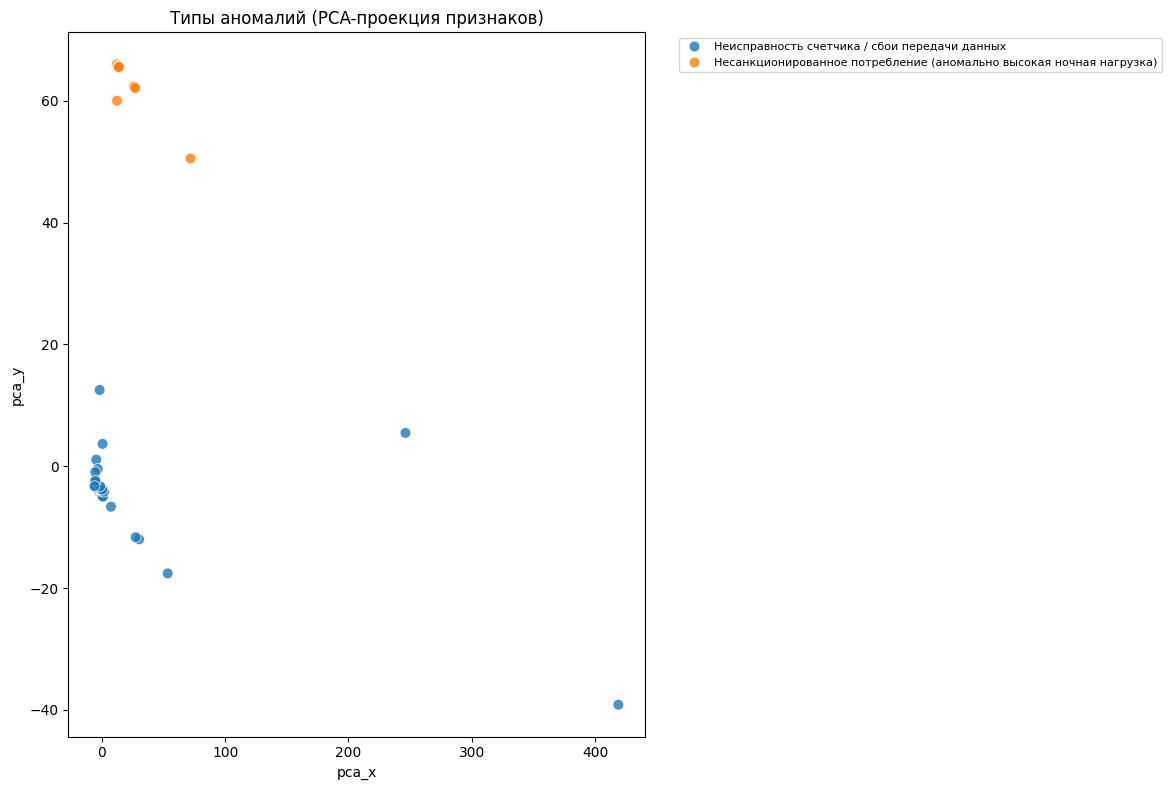

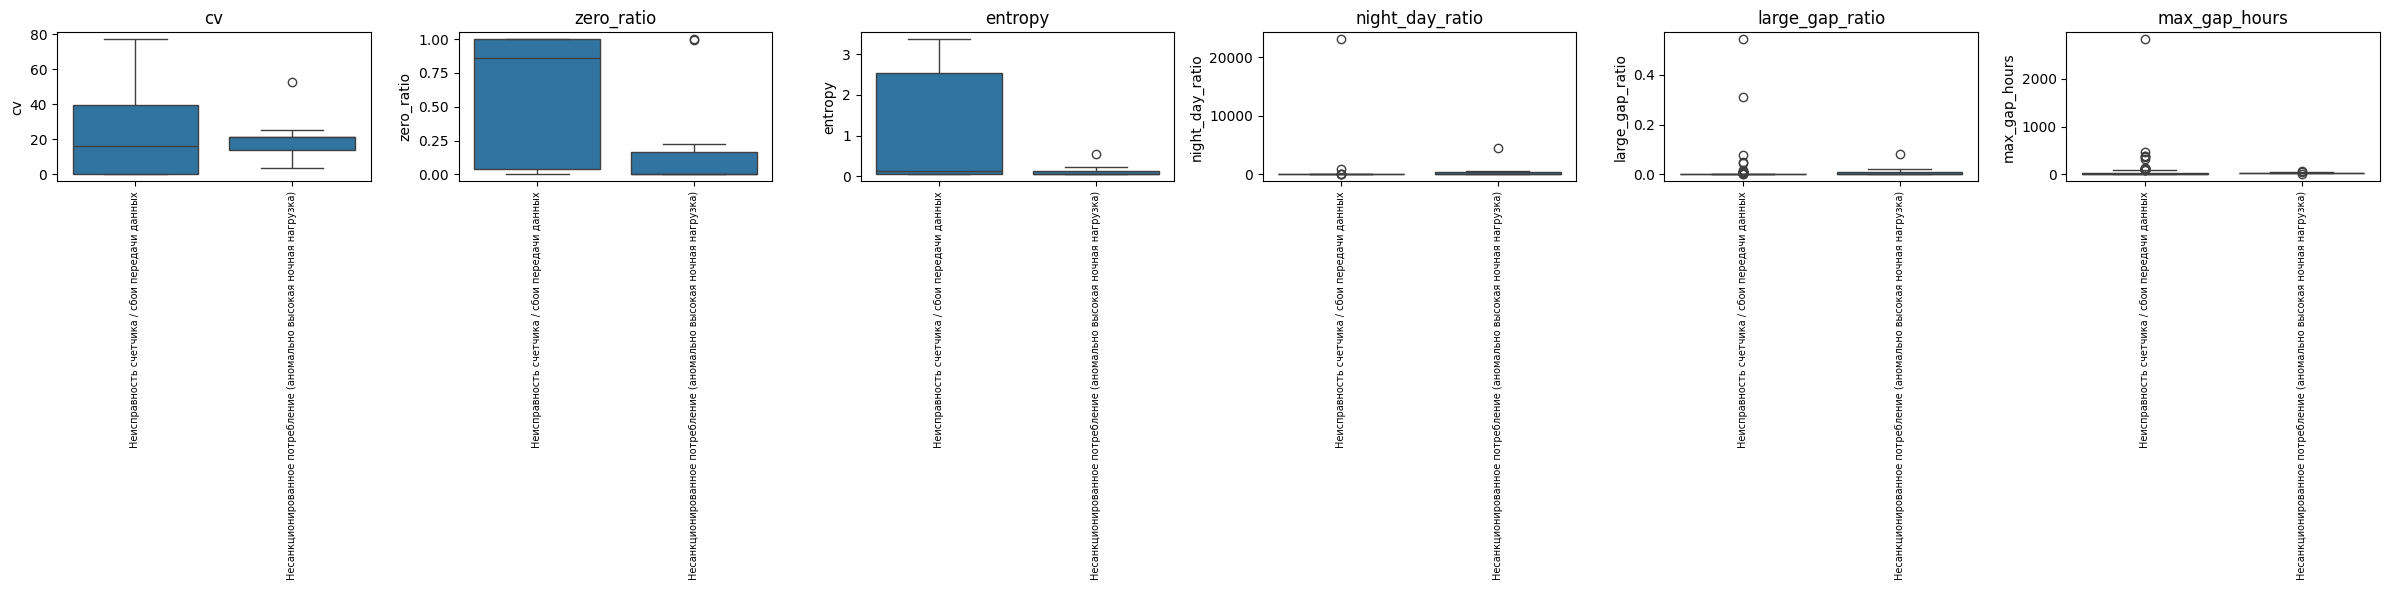

In [15]:
# =====================================================
# ANOMALY TYPE CLUSTERING
# =====================================================

print("\n========== STEP 13: ANOMALY TYPE CLUSTERING ==========")

type_classifier = AnomalyTypeClassifier(n_clusters=4, random_state=42)

clustered_anomalies, cluster_means = type_classifier.fit_predict(
    risk_report=risk_report,
    anomaly_features_df=anomaly_features,
    meter_profiles_df=profiles
)

if not clustered_anomalies.empty:

    print("\nРаспределение аномалий по типам:")
    print(clustered_anomalies["anomaly_type"].value_counts())

    print("\nСредние z-score признаков по кластерам (для интерпретации):")
    print(cluster_means)

    clustered_anomalies.to_csv(
        "data/processed/anomaly_types.csv",
        index=False
    )

    # подмешиваем тип аномалии в финальный отчет отдельной колонкой,
    # не перезаписывая логику предыдущих шагов
    anomaly_type_map = clustered_anomalies.set_index("meter_id")["anomaly_type"]

    risk_report_with_types = risk_report.copy()
    risk_report_with_types["meter_id"] = risk_report_with_types["meter_id"].astype(str).str.strip()
    risk_report_with_types["anomaly_type"] = risk_report_with_types["meter_id"].map(anomaly_type_map)
    risk_report_with_types["anomaly_type"] = risk_report_with_types["anomaly_type"].fillna("Норма")

    risk_report_with_types.to_csv(
        "data/processed/final_risk_report_with_types.csv",
        index=False
    )

    print("Сохранено: data/processed/anomaly_types.csv")
    print("Сохранено: data/processed/final_risk_report_with_types.csv")

    type_visualizer = AnomalyTypeVisualizer(output_dir="image")
    type_visualizer.plot_pca_scatter(clustered_anomalies)
    type_visualizer.plot_feature_distributions(clustered_anomalies)

else:
    print("Аномалии не найдены (anomaly == -1 отсутствуют) — кластеризация типов пропущена.")


========== STEP 14: TRANSITION RISK MODEL ==========
Period features shape: (15122, 17)
Periods per meter:
count    7568.000000
mean        1.998150
std         0.042973
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: period_idx, dtype: float64

Разметка периодов через Isolation Forest:
  Аномальных периодов: 757 / 15122 (5.0%)

Построение датасета переходов (period_0 -> label period_1):
  Счётчиков с обоими периодами: 7554
  Датасет переходов: 7554 строк
  Переходов в аномалию (target=1): 369 (4.9%)

Обучение классификатора переходов:

===== TRANSITION RISK: CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1787
           1       0.62      0.13      0.21       102

    accuracy                           0.95      1889
   macro avg       0.79      0.56      0.59      1889
weighted avg       0.93      0.95      0.93      1889

ROC-AUC: 0.9033

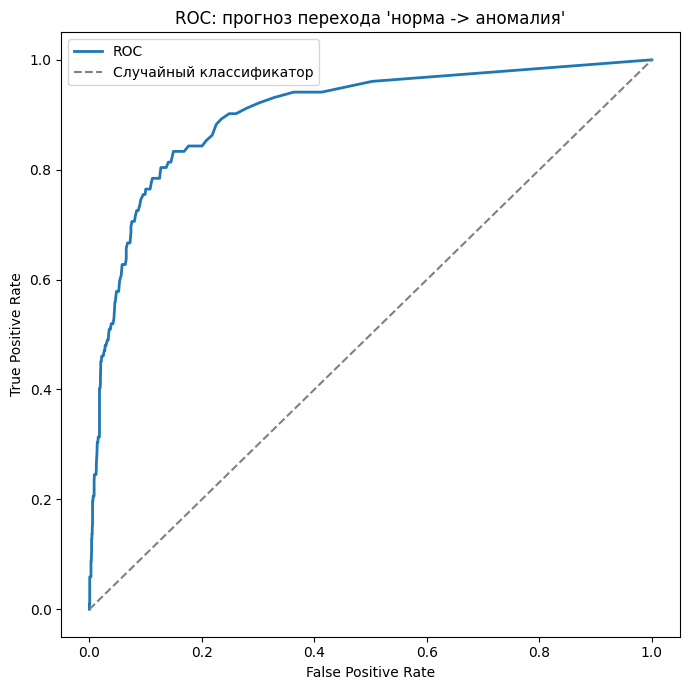

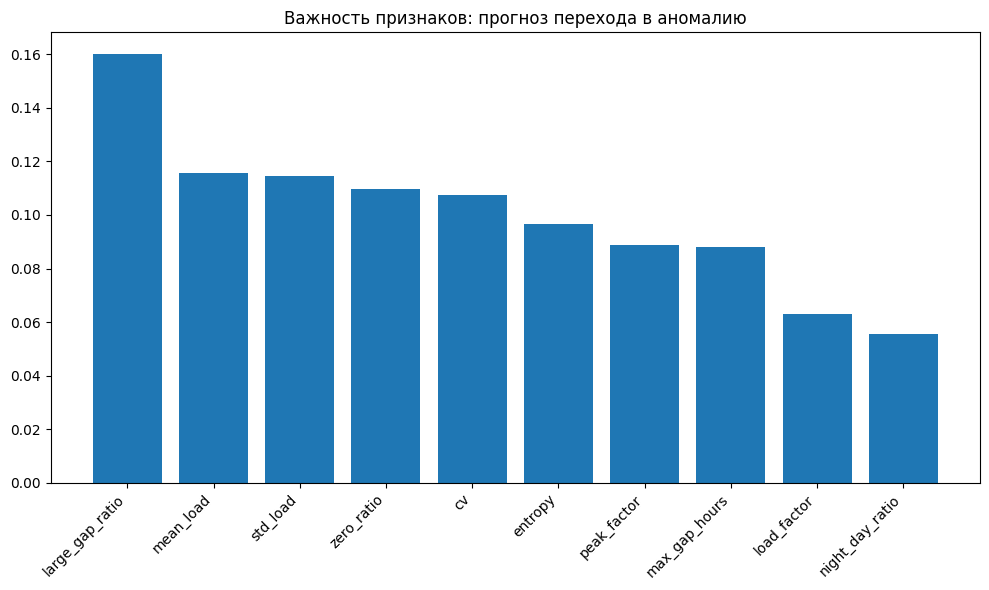


Топ-10 счётчиков по вероятности перехода в аномалию:
                  meter_id      consumer_class        period_start  \
0  04:97:90:01:F0:00:C3:3D   halfhours_group_5 2024-10-21 04:30:00   
1  04:97:90:01:F0:05:A8:53   halfhours_group_1 2024-12-24 15:00:00   
2  04:97:90:01:F0:05:92:CC   halfhours_group_1 2024-10-10 01:00:00   
3  04:97:90:00:11:29:58:53  halfhours_group_13 2024-12-28 15:00:00   
4  04:97:90:00:11:49:23:5A  halfhours_group_16 2024-11-26 20:30:00   
5  04:97:90:00:11:37:E2:C7  halfhours_group_13 2024-10-31 04:00:00   
6  04:97:90:00:11:42:ED:32  halfhours_group_16 2024-10-27 15:30:00   
7  04:97:90:01:F0:09:57:4D   halfhours_group_5 2025-01-30 13:30:00   
8  04:97:90:00:11:42:AE:71  halfhours_group_16 2024-10-26 04:30:00   
9  04:97:90:01:F0:05:D8:15   halfhours_group_1 2024-10-10 04:00:00   

           period_end  transition_risk_proba  
0 2024-12-30 08:15:00               0.950000  
1 2025-01-28 06:30:00               0.930000  
2 2024-12-24 20:30:00             

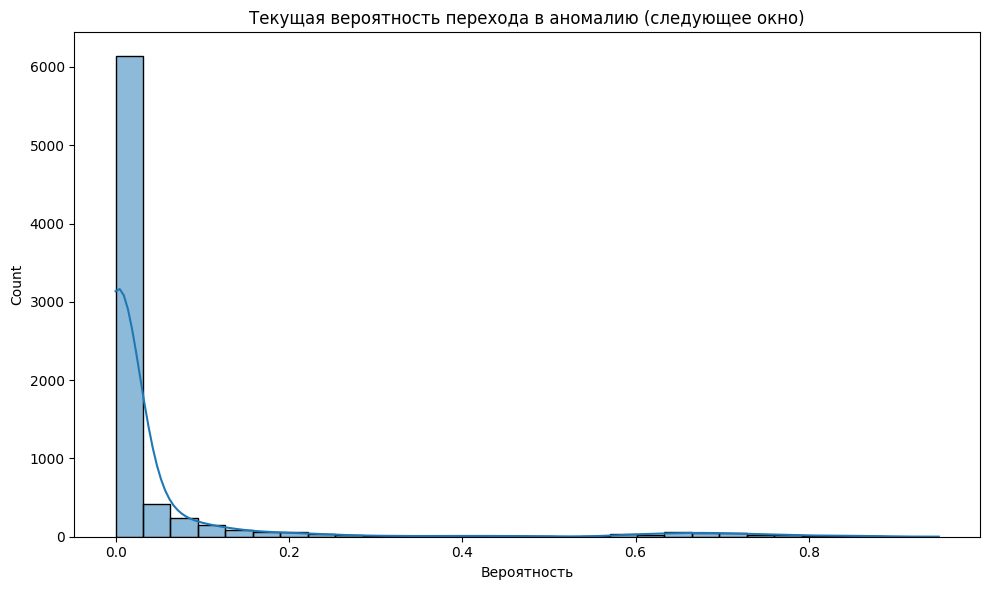


Сохранено: data/processed/period_features.csv
Сохранено: data/processed/transition_risk_current.csv

Pipeline finished successfully!


In [16]:
from src.windowed_anomaly_features import PeriodFeatureExtractor
from src.transition_risk_model import TransitionRiskModel
from src.transition_risk_visualizer import TransitionRiskVisualizer

print("\n========== STEP 14: TRANSITION RISK MODEL ==========")

# Делим ряд каждого счётчика на 2 равных периода по времени.
# Признаки period_0 (первая половина) -> метка period_1 (вторая половина).
period_extractor = PeriodFeatureExtractor(n_periods=2, min_measurements=10)

period_features = period_extractor.extract(df)

print("Period features shape:", period_features.shape)
print("Periods per meter:")
print(period_features.groupby("meter_id")["period_idx"].count().describe())

period_features.to_csv(
    "data/processed/period_features.csv",
    index=False
)

transition_model = TransitionRiskModel(contamination=0.05, random_state=42)

print("\nРазметка периодов через Isolation Forest:")
labeled_periods = transition_model.label_periods(period_features)

print("\nПостроение датасета переходов (period_0 -> label period_1):")
X_trans, y_trans, meta_trans = transition_model.build_transition_dataset(labeled_periods)

if y_trans.nunique() < 2 or len(X_trans) < 20:
    print("Недостаточно данных/классов для обучения — попробуй увеличить contamination.")
else:
    print("\nОбучение классификатора переходов:")
    results = transition_model.train(X_trans, y_trans, meta_trans, test_size=0.25)

    print("\n===== TRANSITION RISK: CLASSIFICATION REPORT =====")
    print(results["report"])
    print(f"ROC-AUC: {results['roc_auc']:.4f}")

    transition_visualizer = TransitionRiskVisualizer(output_dir="image")

    transition_visualizer.plot_roc_curve(
        results["y_test"],
        results["y_proba"]
    )

    transition_visualizer.plot_feature_importance(
        transition_model.classifier,
        TransitionRiskModel.FEATURE_COLUMNS
    )

    current_risk = transition_model.predict_risk(period_features)

    current_risk.to_csv(
        "data/processed/transition_risk_current.csv",
        index=False
    )

    print("\nТоп-10 счётчиков по вероятности перехода в аномалию:")
    print(current_risk.head(10))

    transition_visualizer.plot_risk_distribution(current_risk)

    print("\nСохранено: data/processed/period_features.csv")
    print("Сохранено: data/processed/transition_risk_current.csv")

print("\nPipeline finished successfully!")

In [17]:
print(df.groupby("meter_id")["timestamp"].agg(["min", "max", "count"]).describe())

                                 min                            max  \
count                           7573                           7573   
mean   2024-11-04 05:49:16.107223296  2025-03-10 10:48:44.257229568   
min              2024-10-10 00:00:00            2024-10-26 14:00:00   
25%              2024-10-10 00:00:00            2025-03-10 15:30:00   
50%              2024-10-10 00:00:00            2025-03-10 17:00:00   
75%              2024-11-13 17:30:00            2025-03-10 18:00:00   
max              2025-03-10 12:00:00            2025-03-10 23:30:00   
std                              NaN                            NaN   

             count  
count  7573.000000  
mean   4937.200449  
min       1.000000  
25%    3634.000000  
50%    5441.000000  
75%    6935.000000  
max    7291.000000  
std    2140.231791  


In [18]:
print(df["timestamp"].head(10))

print(df["timestamp"].dtype)

0   2024-10-10
1   2024-10-10
2   2024-10-10
3   2024-10-10
4   2024-10-10
5   2024-10-10
6   2024-10-10
7   2024-10-10
8   2024-10-10
9   2024-10-10
Name: timestamp, dtype: datetime64[ns]
datetime64[ns]
